# AI Experiment Prioritization — IJAH Analytics — Kelompok 7

**Proof-of-Concept**: AI Experiment Prioritization untuk IJAH Analytics Menguji apakah pendekatan menggabungkan confidence, jumlah bukti, novelty, dan potensi sinergi jadi satu skor prioritas eksperimen bisa berjalan dan menghasilkan urutan yang masuk akal.

Karena kelompok 7 belum punya akses ke data BLM-NII/NIMS asli IJAH, PoC ini memakai data sintetis yang strukturnya meniru fitur yang sudah didefinisikan (confidence_score, source_count, interaction_count), ditambah nims_synergy_score.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
N = 1000  # jumlah pasangan senyawa-protein dummy

### Bangkitkan data dari 3 arketipe kandidat
Supaya datanya representatif, bukan random seragam. Ada kandidat yang benar-benar menjanjikan (Promising), kandidat yang masih eksploratif (Exploratory), dan kandidat yang sudah banyak diteliti tapi potensinya rendah (Established).

In [4]:
archetypes = {
    "Promising":   {"n": 300, "confidence": (6, 2), "source_lambda": 3.0,
                     "interaction_scale": 1.5, "synergy": (6, 2)},
    "Exploratory": {"n": 450, "confidence": (3, 3), "source_lambda": 1.2,
                     "interaction_scale": 4.0, "synergy": (3, 3)},
    "Established":  {"n": 250, "confidence": (2, 4), "source_lambda": 4.0,
                     "interaction_scale": 8.0, "synergy": (2, 4)},
}

rows = []
for arche_name, p in archetypes.items():
    n = p["n"]
    confidence_score = np.random.beta(*p["confidence"], n)
    source_count = np.random.poisson(p["source_lambda"], n)
    interaction_count = np.random.exponential(p["interaction_scale"], n)
    nims_synergy_score = np.random.beta(*p["synergy"], n)
    rows.append(pd.DataFrame({
        "confidence_score": confidence_score,
        "source_count": source_count,
        "interaction_count": interaction_count,
        "nims_synergy_score": nims_synergy_score,
        "archetype": arche_name,
    }))

df = pd.concat(rows, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df["compound_id"] = [f"C{i:04d}" for i in range(N)]
df["protein_id"] = [f"P{i:04d}" for i in range(N)]
df.head()

,confidence_score,source_count,interaction_count,nims_synergy_score,archetype,compound_id,protein_id
0,0.528152,1,2.315457,0.516864,Exploratory,C0000,P0000
1,0.408394,1,1.686254,0.811116,Exploratory,C0001,P0001
2,0.570761,2,5.557841,0.648044,Exploratory,C0002,P0002
3,0.316883,2,3.337581,0.470458,Exploratory,C0003,P0003
4,0.736985,0,0.419204,0.253854,Exploratory,C0004,P0004


### Hitung novelty_score dan normalisasi source_count

In [5]:
df["novelty_score"] = 1 / (1 + df["interaction_count"])
df["source_count_norm"] = (df["source_count"].clip(upper=7)) / 7

### Skor gabungan AI Experiment Prioritization (weighted sum)

In [6]:
W_CONFIDENCE = 0.4
W_EVIDENCE = 0.2
W_NOVELTY = 0.2
W_SYNERGY = 0.2

df["priority_score"] = (
    W_CONFIDENCE * df["confidence_score"] +
    W_EVIDENCE * df["source_count_norm"] +
    W_NOVELTY * df["novelty_score"] +
    W_SYNERGY * df["nims_synergy_score"]
)

df["priority_label"] = pd.cut(
    df["priority_score"], bins=[-1, 0.34, 0.52, 2],
    labels=["Rendah", "Sedang", "Tinggi"]
)

### Ground truth sintetis & evaluasi (Average Precision, Precision@10)

In [7]:
latent_quality = (
    0.5 * df["confidence_score"] +
    0.3 * df["nims_synergy_score"] +
    0.2 * df["novelty_score"] +
    np.random.normal(0, 0.12, N)
)
threshold = np.quantile(latent_quality, 0.80)
df["true_high_priority"] = (latent_quality >= threshold).astype(int)

ap_score = average_precision_score(df["true_high_priority"], df["priority_score"])
top10 = df.sort_values("priority_score", ascending=False).head(10)
precision_at_10 = top10["true_high_priority"].sum() / 10

print(f"Jumlah kandidat dummy diuji             : {N}")
print(f"Average Precision (mirip AUPR)          : {ap_score:.3f}")
print(f"Precision@10 (dari 10 kandidat teratas) : {precision_at_10:.2f}")
print()
print("Distribusi priority_label:")
print(df["priority_label"].value_counts())

Jumlah kandidat dummy diuji             : 1000
Average Precision (mirip AUPR)          : 0.707
Precision@10 (dari 10 kandidat teratas) : 0.90

Distribusi priority_label:
priority_label
Sedang    389
Tinggi    342
Rendah    269
Name: count, dtype: int64


### Clustering (K-Means)
Membuktikan priority_score memang memisahkan kandidat ke kelompok yang berbeda, bukan sekadar skor acak.

In [8]:
feature_cols = ["confidence_score", "source_count_norm", "novelty_score", "nims_synergy_score"]
X = StandardScaler().fit_transform(df[feature_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

cluster_order = df.groupby("cluster")["priority_score"].mean().sort_values().index
cluster_rename = {old: new for new, old in enumerate(cluster_order)}
df["cluster"] = df["cluster"].map(cluster_rename)
cluster_names = {0: "Cluster Rendah", 1: "Cluster Sedang", 2: "Cluster Tinggi"}
df["cluster_name"] = df["cluster"].map(cluster_names)

print("Rata-rata priority_score per cluster hasil K-Means:")
print(df.groupby("cluster_name")["priority_score"].agg(["mean", "count"]).round(3))
print()
print("Tabel silang arketipe asli vs cluster K-Means (cek keselarasan):")
print(pd.crosstab(df["archetype"], df["cluster_name"]))

Rata-rata priority_score per cluster hasil K-Means:
                 mean  count
cluster_name                
Cluster Rendah  0.360    455
Cluster Sedang  0.365    188
Cluster Tinggi  0.635    357

Tabel silang arketipe asli vs cluster K-Means (cek keselarasan):
cluster_name  Cluster Rendah  Cluster Sedang  Cluster Tinggi
archetype                                                   
Established               74             169               7
Exploratory              367              16              67
Promising                 14               3             283


### Visualisasi Clustering

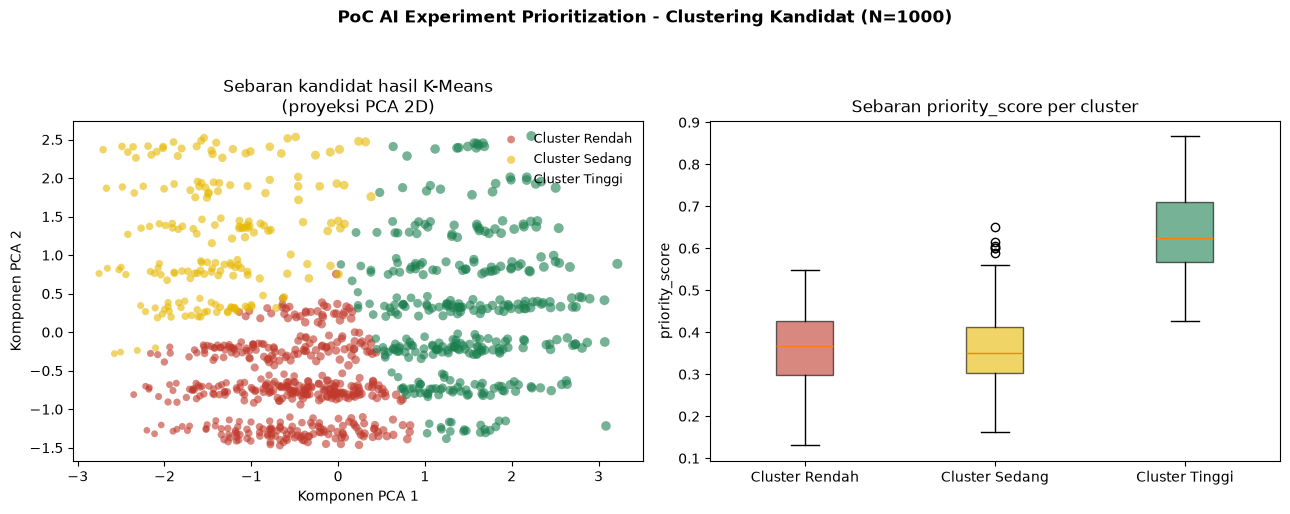

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df["pca1"], df["pca2"] = X_pca[:, 0], X_pca[:, 1]

colors = {"Cluster Rendah": "#C0392B", "Cluster Sedang": "#E6B800", "Cluster Tinggi": "#1B7F4F"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
for cname, color in colors.items():
    sub = df[df["cluster_name"] == cname]
    ax.scatter(sub["pca1"], sub["pca2"], s=18 + sub["priority_score"] * 40,
               c=color, alpha=0.6, edgecolors="none", label=cname)
ax.set_title("Sebaran kandidat hasil K-Means\n(proyeksi PCA 2D)")
ax.set_xlabel("Komponen PCA 1")
ax.set_ylabel("Komponen PCA 2")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
order = ["Cluster Rendah", "Cluster Sedang", "Cluster Tinggi"]
data_box = [df[df["cluster_name"] == c]["priority_score"] for c in order]
bp = ax.boxplot(data_box, tick_labels=order, patch_artist=True)
for patch, cname in zip(bp["boxes"], order):
    patch.set_facecolor(colors[cname])
    patch.set_alpha(0.6)
ax.set_title("Sebaran priority_score per cluster")
ax.set_ylabel("priority_score")

fig.suptitle("PoC AI Experiment Prioritization - Clustering Kandidat (N=1000)", fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()